# Comparison of the HHL to the Thomas for various different Forcing functions, Wave Numbers in 1D and 2D

## To - do:
1. 1D sin function, dirchlet b-c's, small wave number, 2x2 #
2. 1D sin function, dirchlet b-c's, small wave number, 4x4 #
3. 1D sin function, dirchlet b-c's, small wave number, 8x8 #
4. 1D sin function, dirchlet b-c's, large wave number, 4x4 #

5. 1D sin function, dirchlet + neumann b-c's, small wave number, 4x4
6. 1D sin function, robin b-c's, small wave number, 4x4


7. 1D step function, dirchlet b-c's, small wave number, 4x4
8. 1D step function, dirchlet b-c's, small wave number, 8x8
9. 1D step function, dirchlet b-c's, large wave number, 4x4

10. 1D impulse function, dirchlet b-c's, small wave number, 4x4
11. 1D impulse function, dirchlet b-c's, small wave number, 8x8
12. 1D impulse function, dirchlet b-c's, large wave number, 4x4

*Maybe*: 
Varying wave numbers i.e. k is a funciton of domain
Complex grid domains i.e. cavities, obstacles

Import necessary modules

In [2]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
import time
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile
from scipy.sparse import diags
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the maximum absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
    
    
def get_solution_vector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    start = 2**(N-1)
    fin = 2**(N-1) + len(vector)
    solution_vector = Statevector(solution.state).data[start:fin].real
    norm = solution.euclidean_norm
    return norm*solution_vector / np.linalg.norm(solution_vector)


### 1D sin function testing

C:\Users\richa\AppData\Local\Temp\ipykernel_21964\451868879.py:2: DeprecationWarning: The property ``qiskit.utils.algorithm_globals.QiskitAlgorithmGlobals.massive`` is deprecated as of qiskit 0.45.0. It will be removed in the Qiskit 1.0 release. This algorithm utility belongs to a legacy workflow and has no replacement.
  algorithm_globals.massive = True


Updated trotter steps to 24
Updated trotter steps to 11

 Number of ancilla qubits 
:  0

 Number of flag qubits 
:  1

 Number of clock qubits 
:  4

 Number of b qubits 
:  1
Updated trotter steps to 111
Updated trotter steps to 6

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  2
Updated trotter steps to 645
Updated trotter steps to 10

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3


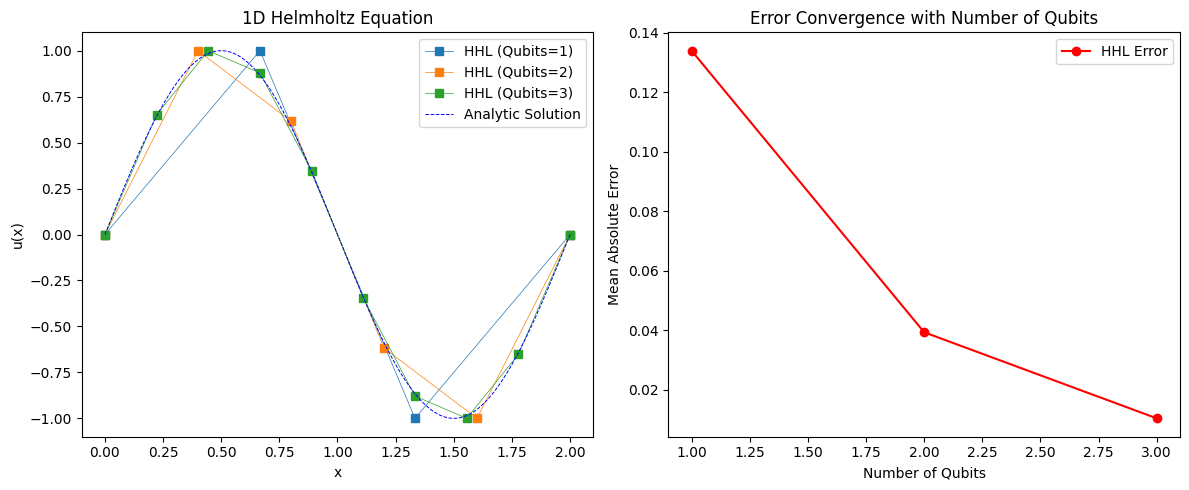

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Gradient of the log curve for error convergence: -1.2797


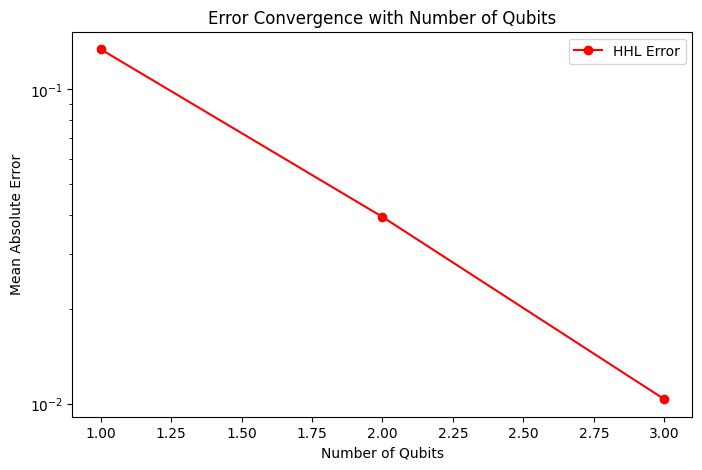

In [ ]:
# Build the matrix A
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS
# Define the number of qubits to test
qubit_numbers = [1, 2, 3]

# Initialize lists to store results
errors_hhl = []
errors_thomas = []

# Plot the results for each qubit number on a single graph
plt.figure(figsize=(12, 5))

# Loop over different qubit numbers
for NUM_QUBITS in qubit_numbers:
    MATRIX_SIZE = 2 ** NUM_QUBITS
    L = 2.0                                     # Domain length
    N = MATRIX_SIZE                             # No. of points
    h = L / (N+1)                               # Step size
    k = 1.0                                     # Wavenumber (avoid k = nπ for stability!)
    eps = 0.01                                  # Error tolerance
    x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points

    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()

    vector = (k**2 - np.pi**2) * np.sin(np.pi * x_numerical)

    x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
    u_analytic = np.sin(np.pi * x_fine)
    u_error = np.sin(np.pi * x_numerical)

    # Construct TridiagonalToeplitz matrix circuit with fixed trotter_steps
    tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b)

    # Tridiagonal Toeplitz HHL
    tridi_hhl = HHL(epsilon=eps)
    tridi_solution = tridi_hhl.solve(tridi_mat, vector)

    tridi_vector = get_solution_vector(tridi_solution, tridi_solution.state.num_qubits, vector)
    tridi_vector = np.concatenate(([0], tridi_vector, [0]))
    tridi_vector = normalize(tridi_vector, -1, 1)

    mae_hhl = np.mean(np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error))
    errors_hhl.append(mae_hhl)

    # Compare to thomas
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    num_solution = normalize(num_solution, -1, 1)

    mae_thomas = np.mean(np.abs(num_solution[1:len(num_solution)-1] - u_error))
    errors_thomas.append(mae_thomas)

    # Plot the results for each qubit number
    plt.subplot(1, 2, 1)
    plt.plot(np.concatenate(([0], x_numerical, [L])), tridi_vector, 's-', linewidth=0.5, label=f'HHL (Qubits={NUM_QUBITS})')
    #plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, '*-', linewidth=0.7, label=f'Thomas Algorithm (Qubits={NUM_QUBITS})')

# Plot the analytic solution
plt.subplot(1, 2, 1)
plt.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('1D Helmholtz Equation')
plt.legend()

# Plot the error convergence
plt.subplot(1, 2, 2)
plt.plot(qubit_numbers, errors_hhl, 'ro-', label='HHL Error')
#plt.plot(qubit_numbers, errors_thomas, 'kx-', label='Thomas Error')
plt.xlabel('Number of Qubits')
plt.ylabel('Mean Absolute Error')
plt.title('Error Convergence with Number of Qubits')
plt.legend()

plt.tight_layout()
plt.show()

# add a log plot for the error convergence
plt.figure(figsize=(8, 5))
plt.plot(qubit_numbers, errors_hhl, 'ro-', label='HHL Error')
plt.yscale('log')
plt.xlabel('Number of Qubits')
plt.ylabel('Mean Absolute Error')
plt.title('Error Convergence with Number of Qubits')    
plt.legend()

# print the gradient of the log curve for error convergence
from scipy.stats import linregress
res = linregress(qubit_numbers, np.log(errors_hhl))
print(f"Gradient of the log curve for error convergence: {res.slope:.4f}")

### 1D sin function testing 
Perform tests for a large wave number and with thomas algorithm

C:\Users\richa\AppData\Local\Temp\ipykernel_21964\3822409559.py:3: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  instance = QuantumInstance(backend)


matrix condition 4.549739247933646
Updated trotter steps to 645
Updated trotter steps to 3

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
HHL Mean Absolute Error for N = 0: 0.01106251475160961
Thomas Mean Absolute Error for N = {2^3}: 0.010936082940740388


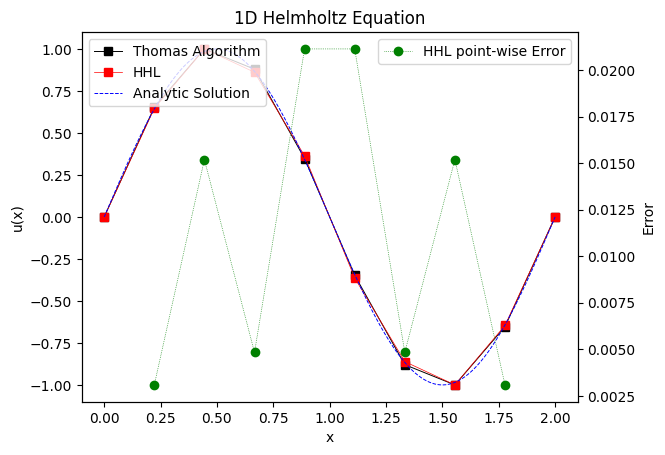

C:\Users\richa\AppData\Local\Temp\ipykernel_21964\3822409559.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\richa\AppData\Local\Temp\ipykernel_21964\3822409559.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


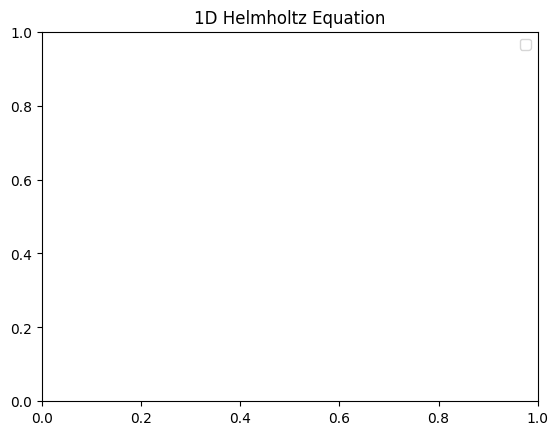

In [6]:
from qiskit.utils import QuantumInstance
backend = Aer.get_backend('statevector_simulator')
instance = QuantumInstance(backend)
# Build the matrix A
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS


L = 2.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
k = 10.0                                   # Wavenumber (avoid k = nπ for stability!)
eps = 0.1                                # Error tolerance
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points


a = -2/h**2 + k**2  # main diagonal
b = 1/h**2          # off diagonal

matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
print('matrix condition', np.linalg.cond(matrix))
vector = ( k**2 - np.pi**2) * np.sin(np.pi * x_numerical) 
#print('Vector:', vector)


x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
u_analytic = np.sin(np.pi * x_fine)
u_error = np.sin(np.pi * x_numerical)

# Construct TridiagonalToeplitz matrix circuit with fixed trotter_steps
tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b, trotter_steps=10)

# Tridiagonal Toeplitz HHL
tridi_hhl = HHL(epsilon=eps)
tridi_hhl.quantum_instance = instance
tridi_solution = tridi_hhl.solve(tridi_mat, vector)
   

tridi_vector = get_solution_vector(tridi_solution, tridi_solution.state.num_qubits, vector)
tridi_vector = np.concatenate(([0], tridi_vector, [0]))
tridi_vector = normalize(tridi_vector, -1, 1)

real_domain = np.concatenate(([0], x_numerical, [L]))

mae = np.mean(np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error))
print(f'HHL Mean Absolute Error for N = {2^2}:', mae)

# Compare to thomas
thomas = numerical_solvers()
num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
num_solution = np.concatenate(([0], num_solution, [0]))
num_solution = normalize(num_solution, -1, 1)
#print(num_solution)
# Evaluate the MAE
mae = np.mean(np.abs(num_solution[1:len(num_solution)-1] - u_error))
print('Thomas Mean Absolute Error for N = {2^3}:', mae)

# Create a plot
real_domain = np.concatenate(([0], x_numerical, [L]))

# Plot the results
fig, ax1 = plt.subplots()

ax1.plot(real_domain, num_solution, 'ks-', linewidth=0.7, label='Thomas Algorithm')
ax1.plot(real_domain, tridi_vector, 'rs-', linewidth=0.5, label='HHL')
ax1.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic Solution')
ax1.set_xlabel('x')
ax1.set_ylabel('u(x)')
ax1.set_title('1D Helmholtz Equation')
ax1.legend(loc='upper left')

# Plot point by point error for HHL solution on a secondary y-axis
ax2 = ax1.twinx()
hhl_error = np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error)
ax2.plot(x_numerical, hhl_error, 'go:', linewidth=0.5, label='HHL point-wise Error')
ax2.set_ylabel('Error')
ax2.legend(loc='upper right')

plt.show()
plt.title('1D Helmholtz Equation')
plt.legend()
plt.legend()

Thomas algorithm worse stability than hhl when simulating wave numbers which are close to n*pi, this means that hhl is more stable overall. There is also a no difference in the wave number magnitude when running for different values

### 1D Testing of the Step Forcing function
Evaluating the impact of the step function as an input forcing function as well as the dependence on wave number of the algo.


Testing for wave number k = 1.0
Matrix condition: 10.463127536183748
Updated trotter steps to 884
Updated trotter steps to 8

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  2


C:\Users\richa\AppData\Local\Temp\ipykernel_17380\4190761098.py:53: RuntimeWarning: invalid value encountered in divide
  pct_diff_pointwise = np.abs((thomas_sol - hhl_sol) / thomas_sol) * 100


Average percent difference between Thomas and HHL solutions: 0.57%

Testing for wave number k = 5.0
Matrix condition: 6.85410196624969
Updated trotter steps to 884
Updated trotter steps to 19

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  4

 Number of b qubits 
:  2


C:\Users\richa\AppData\Local\Temp\ipykernel_17380\4190761098.py:53: RuntimeWarning: invalid value encountered in divide
  pct_diff_pointwise = np.abs((thomas_sol - hhl_sol) / thomas_sol) * 100


Average percent difference between Thomas and HHL solutions: 3730540623371867.00%

Testing for wave number k = 10.0
Matrix condition: 9.47213595499956
Updated trotter steps to 884
Updated trotter steps to 7

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  2


...

Average percent difference between Thomas and HHL solutions: 162.29%

Testing for wave number k = 50.0
Matrix condition: 1.0335754510042061
Updated trotter steps to 884
Updated trotter steps to 1

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  4

 Number of b qubits 
:  2


C:\Users\richa\AppData\Local\Temp\ipykernel_17380\4190761098.py:53: RuntimeWarning: invalid value encountered in divide
  pct_diff_pointwise = np.abs((thomas_sol - hhl_sol) / thomas_sol) * 100


Average percent difference between Thomas and HHL solutions: 1684.87%

Testing for wave number k = 100.0
Matrix condition: 1.0081640141454062
Updated trotter steps to 884
Updated trotter steps to 1

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  4

 Number of b qubits 
:  2
Average percent difference between Thomas and HHL solutions: 2233.60%


C:\Users\richa\AppData\Local\Temp\ipykernel_17380\4190761098.py:53: RuntimeWarning: invalid value encountered in divide
  pct_diff_pointwise = np.abs((thomas_sol - hhl_sol) / thomas_sol) * 100


Text(0.5, 1.0, 'Average Percent Difference between Thomas and HHL Solutions')

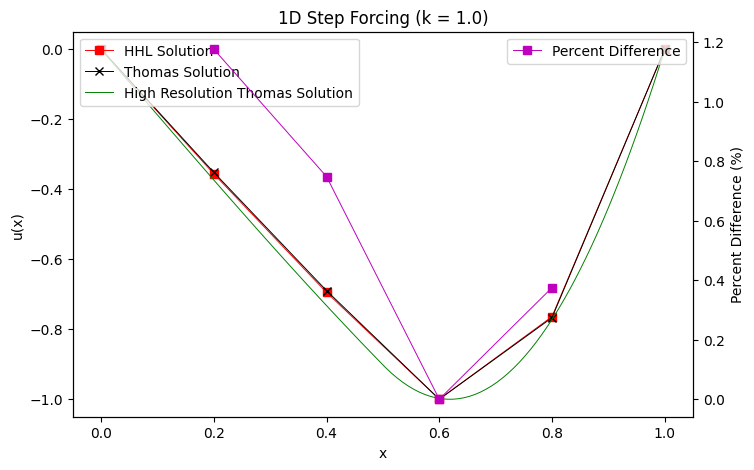

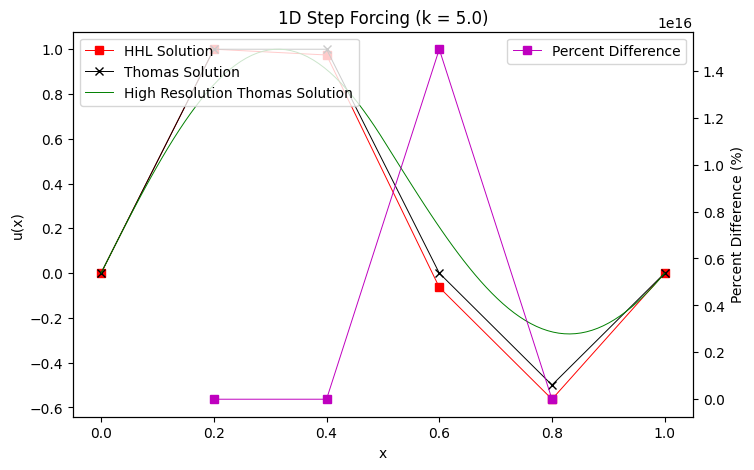

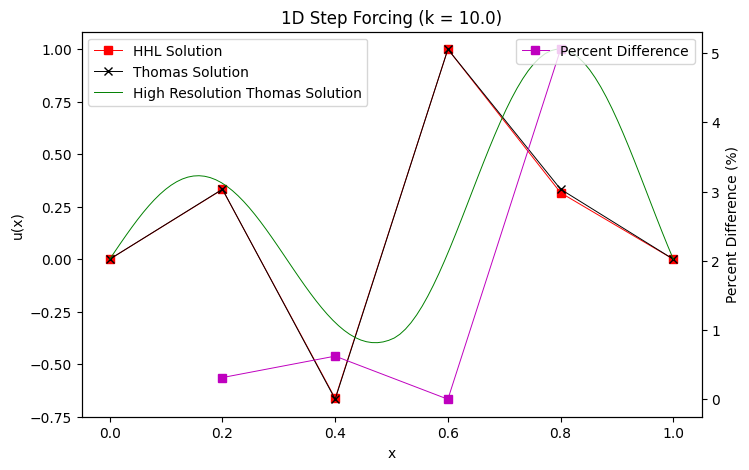

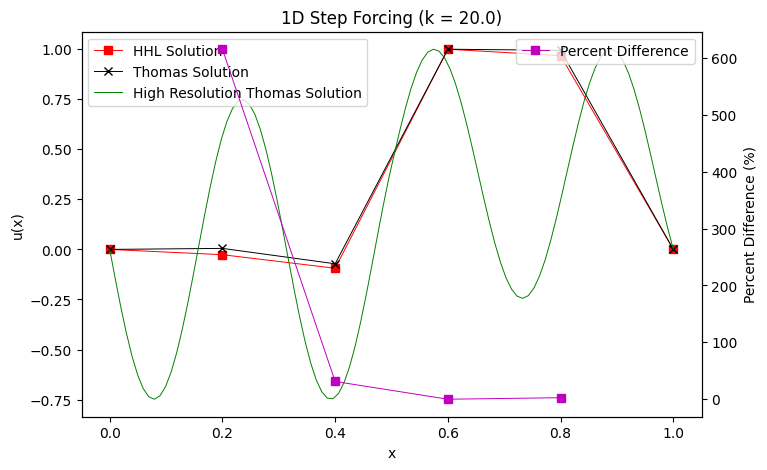

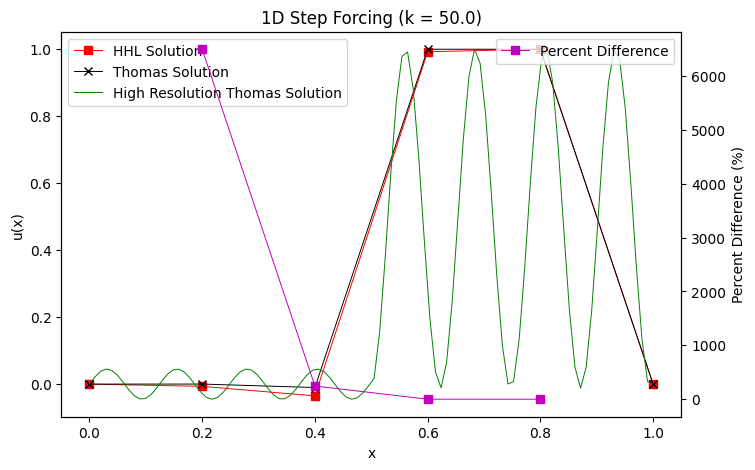

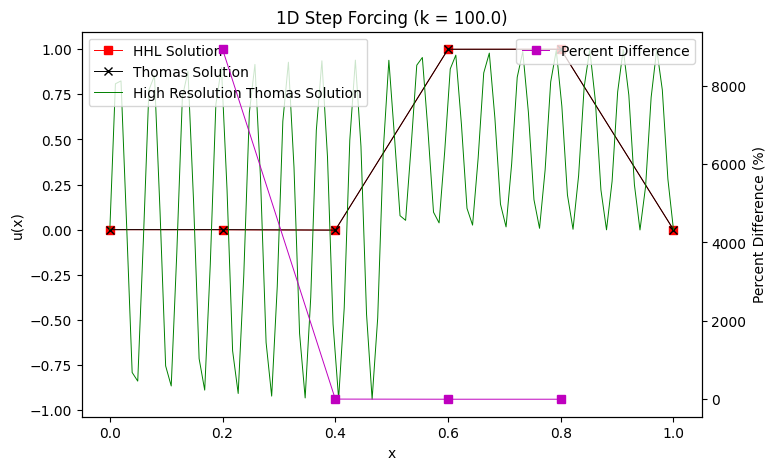

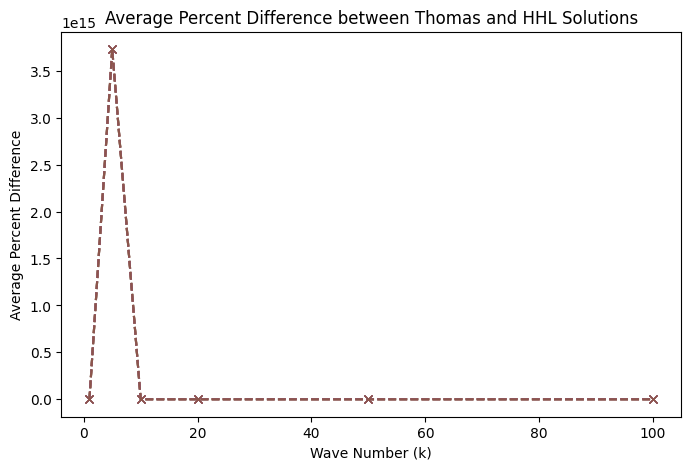

In [5]:

##### NOT WORKING USE THE FUNCTION BELOW
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)
    # --- Compute the Percent Difference at Each Point ---
    pct_diff_pointwise = np.abs((thomas_sol - hhl_sol) / thomas_sol) * 100

    # --- Plot the Percent Difference on a Secondary Axis ---
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label="HHL Solution")
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label="Thomas Solution")
    #ax1.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title("1D Step Forcing (k = {})".format(k))
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_pointwise, 'ms-', linewidth=0.7, label="Percent Difference")
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.savefig('figures/1D_Helmholtz_Step_Forcing_k_{}.png'.format(k))
    

        

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

if __name__ == "__main__":
    # List of wave numbers to test
    wave_numbers = [1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
    #wave_numbers = [1.0, 3.0, 5.0, 7.0]
    # Dictionary to store results for later use/analysis if needed.
    results = {}
    
    for k in wave_numbers:
        print("\nTesting for wave number k = {}".format(k))
        # Set plot=True if you want to see the plot for each wave number.
        domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(k, num_qubits=2, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
        print("Average percent difference between Thomas and HHL solutions: {:.2f}%".format(pct_diff))
        
        results[k] = {
            "wave_numbers" : k,
            "domain": domain,
            "thomas_solution": thomas_sol,
            "hhl_solution": hhl_sol,
            "percent_difference": pct_diff
        }
    

# Plot the pct diff for different wave numbers
plt.figure(figsize=(8, 5))
for k in wave_numbers:
    plt.plot(wave_numbers, [results[k]["percent_difference"] for k in wave_numbers], '--x', label="Percent Difference")
plt.xlabel("Wave Number (k)")
plt.ylabel("Average Percent Difference")
plt.title("Average Percent Difference between Thomas and HHL Solutions")




Results from wave number testing:
**Small wave number accuracy** The HHL is quite accurate for small wave numbers. What this means is that due to the eigenvalues of the finite difference matrix being evenly spaced it is therefore well conditioned and will have a suitable condition number. Hence a higher condition number will make it more accurate. 
**Degradation for large wave numbers** the HHL solution becomes noticeably less accurate and fails to capture the points close to the boundaries usually capturing the correct shape but the incorrect magnitude of the solution. Sort of like a steady state error. This can be tied back to the worsening condition number of the matrix as we increase the wave number This is beacuse the QPE depends on the eigenvalues and it is more difficult for the QPE to get them accurately. Try looking into preconditioning techniques. 

In [10]:
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)
    # Compute the percentage difference at each point
    pct_diff_each_point = np.abs((thomas_sol - hhl_sol) / (thomas_sol + 1e-8)) * 100  # Avoid division by zero

    # Plot the percentage difference on the same graph with a secondary y-axis
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label='Thomas Solution')
    ax1.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Step Forcing (k = {k})")
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 'gs-', linewidth=0.7, label='Percent Difference')
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

real_domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(5.0, num_qubits=4, L=1.0, eps=0.5, plot=True, min_scale=-1.0, max_scale=1.0)
print('error:', pct_diff)


Matrix condition: 79.90551950191724
Updated trotter steps to 34741
Updated trotter steps to 1

 Number of ancilla qubits 
:  3

 Number of flag qubits 
:  1

 Number of clock qubits 
:  8

 Number of b qubits 
:  4


KeyboardInterrupt: 

Accuracy decreases with high wavenumbers not able to accuately capture the large changes

### 1D Testing of the BCs
The main boundary conditions which i will be testing are the dirchlet, neumann and robin
We will be doing this for the step forcing function

In [ ]:
def enforce_neumann_bcs(solution):
    """Apply Neumann BCs using ghost cell method"""
    solution[0] = solution[1]    # Left boundary
    solution[-1] = solution[-2]  # Right boundary
    return solution

def construct_neumann_matrix(N, k, h):
    """Build FD matrix for 1D Helmholtz with Neumann BCs"""
    matrix = np.zeros((N, N))
    h_sq = h**2
    
    # Main diagonal
    np.fill_diagonal(matrix, k**2 - 2/h_sq)
    
    # Off-diagonals with Neumann BC adjustments
    for i in range(N):
        if i > 0: 
            matrix[i, i-1] = 1/h_sq
        if i < N-1: 
            matrix[i, i+1] = 1/h_sq
            
    # Neumann boundary modifications
    matrix[0, 0] = k**2 - 1/h_sq    # Left boundary
    matrix[0, 1] = 1/h_sq
    matrix[-1, -1] = k**2 - 1/h_sq  # Right boundary
    matrix[-1, -2] = 1/h_sq
    
    return matrix


def solve_helmholtz_step_neumann(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # Discretization
    N = 2 ** num_qubits
    h = L / (N + 1)
    x = np.linspace(0, L, N+2)[1:-1]  # Interior points
    
    # Build Neumann matrix
    fd_matrix = construct_neumann_matrix(N, k, h)
    
    print('finite stencil: \n', fd_matrix)
    print('finite stencil condition number:', np.linalg.cond(fd_matrix))
    
    
    # Forcing term (step function)
    f = np.where(x < L/2, 0.0, L)
    
    # HHL Solve
    hhl_solver = HHL(epsilon=eps)
    fd_matrix_circ = NumPyMatrix(fd_matrix)
    hhl_solution = hhl_solver.solve(fd_matrix_circ, f)
    
    # Extract and process solution
    full_solution = get_solution_vector(hhl_solution, hhl_solution.state.num_qubits, f)
    print('HHL solution: \n', full_solution)
    hhl_full = np.concatenate([[0], full_solution, [0]])
    print('HHL full solution:', hhl_full)
    hhl_full = enforce_neumann_bcs(hhl_full)
    print('HHL full solution after enforcing Neumann BCs:', hhl_full)
    hhl_normalized = normalize(hhl_full, min_scale, max_scale)
    print('HHL solution normalized:', hhl_normalized)
    
    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()  # Changed from numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(fd_matrix, f)  # Use original fd_matrix
    thomas_full = np.concatenate([[0], thomas_interior, [0]])
    thomas_full = enforce_neumann_bcs(thomas_full)
    thomas_normalized = normalize(thomas_full, min_scale, max_scale)

    # # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_high_res = np.linspace(0, L, N_high_res + 2)
    x_interior_high_res = x_high_res[1:-1]
    
    matrix_high_res = construct_neumann_matrix(N_high_res, k, h_high_res)
    
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, L)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_full = np.concatenate([[0], hi_thomas_interior, [0]])
    hi_thomas_full = enforce_neumann_bcs(hi_thomas_full)
    hi_thomas_normalized = normalize(hi_thomas_full, min_scale, max_scale)

    # --- Plotting ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_domain = np.linspace(0, L, 1000)
    f_analytic = np.where(analytic_domain < L/2, 0.0, L)
    # Compute the percentage difference at each point
    pct_diff_each_point = np.abs((thomas_normalized - hhl_normalized) / (thomas_normalized + 1e-8)) * 100  # Avoid division by zero

    # Plot the percentage difference on the same graph with a secondary y-axis
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(real_domain, hhl_normalized, 'ro-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_normalized, 'bx--', linewidth=0.7, label='Thomas Solution')
    ax1.plot(x_high_res, hi_thomas_normalized, 'm-', linewidth=0.7, label='High-Res Thomas')
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Step Forcing (k = {k})")
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 'gs-', linewidth=0.7, label='Percent Difference')
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper left')

    plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_normalized[1:-1] - hhl_normalized[1:-1]) / 
                             (thomas_normalized[1:-1] + 1e-8))) * 100  # Avoid division by zero

    return real_domain, thomas_normalized, hhl_normalized, pct_diff

#=======================
# Execution
#=======================

if __name__ == "__main__":
    # Testing usage
    real_domain, thomas_normalized, hhl_normalized, pct_diff = solve_helmholtz_step_neumann(
        k=6.0,
        num_qubits=3,  # 8 points (2^3)
        L=1.0,
        eps=0.01,
        plot=True,
        min_scale=-1.0,
        max_scale=1.0
    )
    print('Percent Difference:', pct_diff)
    # Framework for testing an array of wave numbers
    results = {}

    for k in wave_numbers:
        print(f"Testing for wave number k = {k}")
        real_domain, thomas_normalized, hhl_normalized, pct_diff = solve_helmholtz_step_neumann(
            k=k,
            num_qubits=3,  # 8 points (2^3)
            L=1.0,
            eps=0.01,
            plot=True,
            min_scale=-1.0,
            max_scale=1.0
        )
        results[k] = pct_diff
        print(f'Percent Difference for k={k}:', pct_diff)
        
        # Uncomment the following lines to save the figures
        # plt.savefig(f'neumanntest_wave_number_{k}.png')

    print("Results:", results)
    # Plot the percent difference for different wave numbers
    plt.figure(figsize=(10, 6))
    plt.plot(wave_numbers, [results[k] for k in wave_numbers], 'bo-', linewidth=0.7, label='Percent Difference')
    plt.xlabel("Wave Number (k)")
    plt.ylabel("Percent Difference (%)")
    plt.title("Percent Difference vs Wave Number")
    plt.legend()
    plt.grid(True)
    plt.show()
    

### 1D Testing of Impulse Function
Important to understand how a system reacts to point sources and excitations. This can be solved analytically using greens function. 

In [ ]:
def solve_helmholtz_dirac(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()
    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Dirac Delta Forcing Term ---
    # We choose x0 = L/2 and approximate the delta by setting f(x0) = 1/h so that f(x0)*h ≈ 1.
    x0 = L / 2
    f = np.zeros_like(x_interior)
    idx = np.argmin(np.abs(x_interior - x0))
    f[idx] = 1/h

    # --- Solve using HHL ---
    # (Assuming TridiagonalToeplitz, HHL, get_solution_vector, and normalize are defined elsewhere)
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.zeros_like(x_interior_high_res)
    idx_high = np.argmin(np.abs(x_interior_high_res - x0))
    f_high_res[idx_high] = 1/h_high_res
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Analytic Forcing (Dirac Delta) ---
    analytic_x = np.linspace(0, L, 1000)
    # Represent the Dirac delta as a narrow Gaussian with unit area.
    sigma = 0.01 * L  # Adjust sigma to make the spike narrow
    analytic_delta = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((analytic_x - x0)/sigma)**2)

    # --- Analytic Green's Function Solution ---
    # For u''(x) + k^2 u(x) = delta(x-x0) with u(0)=u(L)=0, the Green's function is:
    #   G(x,x0) = sin(k*x_<)*sin(k*(L-x_>))/(k*sin(k*L))
    analytic_green = np.where(analytic_x < x0,
                              np.sin(k*analytic_x) * np.sin(k*(L - x0)) / (k * np.sin(k*L)),
                              np.sin(k*x0) * np.sin(k*(L - analytic_x)) / (k * np.sin(k*L))
                             )
    analytic_green = -1 * normalize(analytic_green, min_scale, max_scale)

    # --- Optionally Plot the Solutions and Forcing ---
    real_domain = np.linspace(0, L, N + 2)
    pct_diff_each_point = np.abs((thomas_sol - hhl_sol) / (thomas_sol + 1e-8)) * 100  # Avoid division by zero

    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label='Thomas Solution')
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Res Thomas Solution")
    ax1.plot(analytic_x, analytic_green, 'm--', linewidth=1.0, label="Analytic Green's Function")
    ax1.axvline(x=x0, color='c', linestyle='-',linewidth=2.5, label='Impulse Location')
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Dirac Delta Forcing (k = {k})")
    ax1.legend(loc='upper left')

    # Plot the analytic representation of the delta on a secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 's--', linewidth=0.5)
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.show()

    # --- Compute the Mean Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / (thomas_sol[1:-1] + 1e-8))) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

# Example call:
real_domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_dirac(19.0, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
print('error:', pct_diff)


Worth noting stay away from k = n*pi, this has a big impact on the condition number of the matrix. Making it very large and as a result not very well conditioned or suited for the HHL algorithm 
wave numbers:
k = 1 :: Quite accurate thomas and HHL agree well together. And are close to the true analytic solution given by greens equation and also the high resolution thomas solver. Error between the HHL and thomas are most prevalent where there is a large du/dx. condition number = 32
k = 3 :: Matrix error not enough memory
k = 4 :: condition number = 48 ,, Similar sort of trend the largest error occurs when there are high changes in gradient for the solver. MAE = 1.05% still very accurate more than the k = 1 case. Difficulty simulating however the symmetrical nature of the solution only managed to match analytical solution from x >= 0.5. both solvers were inaccurate for x <= 0.5
k = 7 :: This time the opposite able to accurately simulate x <= 0.5 but not x > 0.5. conditon number 24,  MAE 32%. Similar error point by point distribution.
k = 11 :: Similar sort of trend can only simulate one half of the domain accurately and cannot match the high resolution and analytical thomas for one half. MAE 1.8 and condition number = 11. However, one thing to notice is that the wave shapes are becoming more and more oscillaroty as a result a higher number of qubits would in turn be required to actually simulate these effectively ** look into getting more qubits !! we need more memory ** 
k = 19 :: hi res thomas can no longer simulate accurately. condition number is 7.5, MAE 8